# Exercise 1: Summing lists and arrays

Python's built-in function
[`sum()`](https://docs.python.org/3/library/functions.html#sum)
and NumPy's function
[`np.sum()`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)
can both be used to sum sequences of numbers.
In this exercise, we compare the execution time of `sum()` and `np.sum()`
for sequences of different lengths.

1. Create a list `lst` and a NumPy array `arr`, each of them containing the sequence 
   of ten values `0, 1, 2, ..., 9`.

   *Hint*: You can use the list constructor 
   [`list()`](https://docs.python.org/3/library/functions.html#func-list)
   and combine it with the 
   [`range()`](https://docs.python.org/3/library/functions.html#func-range)
   function, which returns an object representing a range of integers.

   *Hint*: You should create the NumPy array using 
   [`np.arange()`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html).

2. We want to compute the sum of integers contained in `lst` and `arr`. Use 
   the built-in function 
   [`sum()`](https://docs.python.org/3/library/functions.html#sum)
   to sum elements of a list.
   For the NumPy array, use the NumPy function 
   [`np.sum()`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html).

3. You are interested in benchmarking which summing function is faster.
   Repeat the steps from above, but use the cell magic 
   [`%timeit`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit)
   to time the execution of a statement as follows:

    ```python
    %timeit statement
    ```

4.  Recreate the list and array to contain 100 integers starting from 0,
    and rerun the benchmark.

5.  Recreate the list and array to contain 10,000 integers starting from 0,
    and rerun the benchmark.


What do you conclude about the relative performance of built-in lists 
vs. NumPy arrays?

### Solution

#### Part 1 — Creating a list and a NumPy array

In [1]:
# Create list with 10 elements 0, 1, ..., 9
lst = list(range(10))

In [2]:
import numpy as np

# Create array with 10 elements 0, 1, ..., 9
arr = np.arange(10)

#### Part 2 — Computing the sum of elements

In [3]:
# Sum the list using the built-in function sum()
sum(lst)

45

In [4]:
# Sum the NumPy array using NumPy's sum() function
np.sum(arr)

np.int64(45)

#### Part 3 — Benchmarking with 10 values

In [5]:
# Benchmark summing list using built-in sum()
%timeit sum(lst)

56.8 ns ± 0.572 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [6]:
# Benchmark summing array using NumPy's sum()
%timeit np.sum(arr)

831 ns ± 9.35 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


As you can see, for a short list, the built-in `sum()` was faster by a factor of about 20 (the exact difference varies depending on your hardware and platform).

#### Part 4 — Benchmarking with 100 values

In [7]:
# Recreate list and array to contain 100 integers starting at 0
N = 100
lst = list(range(N))
arr = np.arange(N)

In [8]:
# Benchmark built-in sum() with 100 elements
%timeit sum(lst)

289 ns ± 3.28 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [9]:
# Benchmark NumPy's sum() with 100 elements
%timeit np.sum(arr)

831 ns ± 8.65 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


For 100 elements, the built-in `sum()` is still faster, but only by a factor of 4 (again, the exact values depend on your platform). Note that the execution time for `np.sum()` remained almost unchanged, which suggests that the function call has a high fixed cost but scales much better with the number of elements to be summed.

#### Part 5 — Benchmarking with 10,000 values

In [10]:
# Recreate list and array to contain 10,000 integers starting at 0
N = 10_000
lst = list(range(N))
arr = np.arange(N)

In [11]:
# Benchmark built-in sum() with 10,000 elements
%timeit sum(lst)

26.1 μs ± 399 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [12]:
# Benchmark NumPy's sum() with 10,000 elements
%timeit np.sum(arr)

1.39 μs ± 10.8 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Lastly, for 10,000 elements, `np.sum()` is substantially faster by a factor of about 15. You should conclude that for large arrays, you can expect much better performance from NumPy's functions, but this may not be true for small datasets.

<span style="display: none;">SolutionEnd</span>

***
# Exercise 2: Maximizing quadratic utility

In economics, we usually represent an individual's preferences with a utility
function, $u(\bullet)$.
Assume that utility from consuming $c$ units is given by the following
quadratic function:
$$
u(c) = - A (c - B)^2 + C
$$

where $A > 0$, $B > 0$, and $C$ are parameters, and $c$ is the consumption
level.
The following code plots the function for specific parameter values. We will
cover plotting in detail in later weeks, so you can ignore the code for now:

Text(0, 0.5, 'Utility')

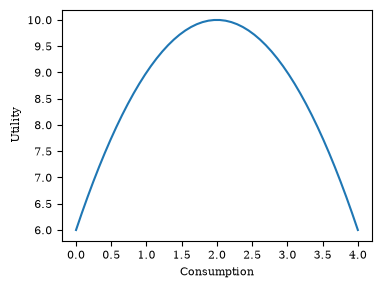

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

c = np.linspace(0, 4, 50)
u = -1 * (c - 2) ** 2 + 10
plt.plot(c, u)
plt.xlabel('Consumption')
plt.ylabel('Utility')

In this exercise, you are asked to locate the consumption level that yields
the maximum utility.

1. Define a function `util()` that takes the consumption level `c` and three
   additional arguments, `A`, `B`, and `C`. These are the parameters of
   $u(\bullet)$ defined above. The function should return the utility associated
   with the consumption level `c`.

   *Hint*: Use the `**` operator for exponentiation in Python. For example,
   `x ** 2` computes the square of `x`.

2. Write a function `find_max_cons()` that takes a sequence of candidate
   consumption levels and the three parameters `A`, `B`, and `C`. The function
   should return the maximum utility and the corresponding consumption level.
   The function definition should look like this:
   ```python
   def find_max_cons(candidates, A, B, C):
       """
       Find the consumption level that maximizes utility from a
       sequence of candidates.

       Parameters
       ----------
       candidates : list or array-like
           Sequence of candidate consumption levels to evaluate.
       A, B, C : float
           Parameters of the utility function.

       Returns
       -------
       u_max
           Maximized utility
       cons_max
           Consumption at which utility is maximized
       """
   ```

   Your algorithm should perform the following steps:

   1. Initialize `u_max` to `-np.inf` (negative infinity).
   2. Loop through all candidate consumption levels and compute the associated
      utility. If this utility is larger than the current maximum value
      `u_max`, update `u_max` and store the associated consumption level
      `cons_max`.
   3. Return `u_max` and `cons_max` after the loop terminates.

3. Find the maximum:
   1. Create an array `cons` containing 51 uniformly spaced candidate
      consumption levels on the interval $[0, 4]$.

      *Hint*: Use
[`np.linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
      for this task.

   2. Use the parameters $A = 1$, $B = 2$, and $C = 10$.
   3. Use `find_max_cons()` to compute the maximum utility and the corresponding
      optimal consumption level, and print the results.

4. Repeat the exercise using vectorized NumPy operations:
   1. Compute and store the utility levels for *all* elements in `cons` at once
      by applying the formula to the entire array.
   2. Locate the index of the maximum utility level using
[`np.argmax()`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html).
   3. Use the index returned by `np.argmax()` to retrieve the maximum utility
      and the corresponding consumption level, and print the results.

### Solution

#### Part 1 — Define the utility function

In [14]:
def util(c, A=1.0, B=2.0, C=10.0):
    """
    Evaluate utility for a given consumption level c.
    """
    u = -A * (c - B) ** 2.0 + C
    return u

#### Part 2 — Define a function to locate the maximum

In [15]:
import numpy as np


def find_max_cons(candidates, A=1.0, B=2.0, C=10.0):
    """
    Find the consumption level that maximizes utility from a
    sequence of candidates.

    Parameters
    ----------
    candidates : list or array-like
        Sequence of candidate consumption levels to evaluate.
    A, B, C : float
        Parameters of the utility function.

    Returns
    -------
    u_max
        Maximized utility
    cons_max
        Consumption at which utility is maximized
    """

    # Initialize max. utility level at the lowest possible value
    u_max = -np.inf

    # Consumption level at which utility is maximized
    cons_max = None

    for c in candidates:
        # Evaluate utility at candidate consumption level
        u = util(c, A, B, C)

        if u > u_max:
            # New maximum found, update utility and optimal consumption
            u_max = u
            cons_max = c

    return u_max, cons_max

#### Part 3 — Find the maximum

In [16]:
# Candidate consumption levels
cons = np.linspace(0.0, 4.0, 51)

# Parameters
A = 1.0
B = 2.0
C = 10.0

In [17]:
# Use function to find maximum
u_max, cons_max = find_max_cons(cons, A, B, C)

# Print maximum and maximizer
print(f'Utility is maximized at c={cons_max} with u={u_max}')

Utility is maximized at c=2.0 with u=10.0


#### Part 4 — Using vectorization with NumPy

In [18]:
# Evaluate all utilities at once using vectorized NumPy operations
u = util(cons, A, B, C)

# Print utility levels
u

array([ 6.    ,  6.3136,  6.6144,  6.9024,  7.1776,  7.44  ,  7.6896,
        7.9264,  8.1504,  8.3616,  8.56  ,  8.7456,  8.9184,  9.0784,
        9.2256,  9.36  ,  9.4816,  9.5904,  9.6864,  9.7696,  9.84  ,
        9.8976,  9.9424,  9.9744,  9.9936, 10.    ,  9.9936,  9.9744,
        9.9424,  9.8976,  9.84  ,  9.7696,  9.6864,  9.5904,  9.4816,
        9.36  ,  9.2256,  9.0784,  8.9184,  8.7456,  8.56  ,  8.3616,
        8.1504,  7.9264,  7.6896,  7.44  ,  7.1776,  6.9024,  6.6144,
        6.3136,  6.    ])

In [19]:
# Locate the index of the maximum
imax = np.argmax(u)

# Recover the utility and the consumption level at the maximum
u_max = u[imax]
cons_max = cons[imax]

print(f'Utility is maximized at c={cons_max} with u={u_max}')

Utility is maximized at c=2.0 with u=10.0


<span style="display: none;">SolutionEnd</span>

***
# Exercise 3: Progressive income taxation

Consider the following simplified, illustrative progressive income-tax
system:

- Income up to NOK 300,000 is not taxed.
- Income from NOK 300,000 to NOK 700,000 is taxed at 20%.
- Income above NOK 700,000 is taxed at 35%.

This schedule is designed for the exercise and does not represent the actual
Norwegian tax system.

1. Define a function `tax()` that takes annual income in NOK as its argument
   and returns the amount of tax owed. Use `if`, `elif`, and `else` to handle
   the three income ranges.

2. Calculate taxes for a sequence of incomes using a loop:

   1. Create an array `incomes` containing 13 evenly spaced values from
      NOK 0 to NOK 1,200,000 using
[`np.linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html).
   2. Create an empty array `taxes_loop` with the same shape as `incomes`.
   3. Loop over `incomes`, evaluate `tax()` for each element, and store the
      result in `taxes_loop`.
   4. Compute the corresponding after-tax incomes.
   5. Print a table with one row per income and columns for gross income,
      tax, and after-tax income. Report all amounts in NOK.

3. Define a function `tax_numpy()` that takes an array of annual incomes and
   returns an array containing the corresponding taxes. The function should
   use vectorized NumPy operations instead of a loop. 
   
   *Hint:* Use
   [`np.maximum()`](https://numpy.org/doc/stable/reference/generated/numpy.maximum.html)
   to prevent taxable amounts from becoming negative and
   [`np.minimum()`](https://numpy.org/doc/stable/reference/generated/numpy.minimum.html)
   to cap the income taxed at 20% at NOK 400,000.

   Call `tax_numpy()` with `incomes` and compute the corresponding after-tax
   incomes. Use
[`np.allclose()`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html)
   to verify that the loop and vectorized calculations produce the same
   taxes and after-tax incomes.

### Solution

#### Part 1 — Define the tax function

In [20]:
def tax(income):
    """
    Compute tax under the simplified progressive schedule.

    Parameters
    ----------
    income : float
        Annual income in NOK.

    Returns
    -------
    float
        Tax owed in NOK.
    """
    if income <= 300_000.0:
        # Income up to NOK 300,000 is tax free.
        tax_owed = 0.0
    elif income <= 700_000.0:
        # Tax only the amount above the tax-free threshold at 20%.
        tax_owed = 0.20 * (income - 300_000.0)
    else:
        # Tax the full lower bracket at 20% and the excess above NOK 700,000 at 35%.
        tax_lower_bracket = 0.20 * (700_000.0 - 300_000.0)
        tax_upper_bracket = 0.35 * (income - 700_000.0)
        tax_owed = tax_lower_bracket + tax_upper_bracket

    return tax_owed

#### Part 2 — Calculate taxes using a loop

In [21]:
import numpy as np

# Annual incomes from NOK 0 to NOK 1,200,000
incomes = np.linspace(0.0, 1_200_000.0, 13)

# Calculate taxes one income at a time
taxes_loop = np.empty_like(incomes)
for i, income in enumerate(incomes):
    taxes_loop[i] = tax(income)

net_incomes = incomes - taxes_loop

# Tabulate gross income, tax, and after-tax income in NOK
print(f'{"Gross income":>15} {"Tax":>15} {"After-tax income":>18}')
for i, income in enumerate(incomes):
    print(f'{income:15,.0f} {taxes_loop[i]:15,.0f} {net_incomes[i]:18,.0f}')

   Gross income             Tax   After-tax income
              0               0                  0
        100,000               0            100,000
        200,000               0            200,000
        300,000               0            300,000
        400,000          20,000            380,000
        500,000          40,000            460,000
        600,000          60,000            540,000
        700,000          80,000            620,000
        800,000         115,000            685,000
        900,000         150,000            750,000
      1,000,000         185,000            815,000
      1,100,000         220,000            880,000
      1,200,000         255,000            945,000


#### Part 3 — Define a vectorized NumPy function

In [22]:
def tax_numpy(incomes):
    """
    Compute taxes for an array of incomes using NumPy operations.

    Parameters
    ----------
    incomes : array
        Annual incomes in NOK.

    Returns
    -------
    array
        Taxes owed in NOK.
    """
    # Limit income taxed at 20% to the NOK 300,000-700,000 bracket.
    lower_bracket_income = np.minimum(np.maximum(incomes - 300_000.0, 0.0), 400_000.0)
    # Only income above NOK 700,000 is taxed at 35%.
    upper_bracket_income = np.maximum(incomes - 700_000.0, 0.0)

    # Add the tax owed in each bracket for every income.
    taxes = 0.20 * lower_bracket_income + 0.35 * upper_bracket_income
    return taxes


taxes_vectorized = tax_numpy(incomes)
net_income_vectorized = incomes - taxes_vectorized

# Compare arrays with a tolerance to allow for floating-point rounding.
taxes_agree = np.allclose(taxes_loop, taxes_vectorized)
net_incomes_agree = np.allclose(net_incomes, net_income_vectorized)

print(f'Tax calculations agree: {taxes_agree}')
print(f'After-tax incomes agree: {net_incomes_agree}')

Tax calculations agree: True
After-tax incomes agree: True


The two functions produce identical results. The scalar function `tax()`
uses Python conditionals for one income, whereas `tax_numpy()` applies
vectorized operations to an entire NumPy array.

<span style="display: none;">SolutionEnd</span>